# Figure 4 Jupyter Notebook

## Imports and Common Functions

In [1]:
import glob
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
def sort_func(filename):
    file_parts = filename.split('_')
    try:
        return int(file_parts[-1].split('.')[0])
    except ValueError:
        return 0


def shrink_array(arr, factor):
    """Re-bin an array by an integer factor.
    In the new array, each bin is the sum of the original bins.
    """
    old_shape = arr.shape
    new_shape = (old_shape[0] // factor, old_shape[1] // factor)
    new_arr = np.zeros(new_shape)
    for i in range(new_shape[0]):
        for j in range(new_shape[1]):
            new_arr[i, j] = np.sum(arr[i*factor:(i+1)*factor, j*factor:(j+1)*factor])
    return new_arr


def shrink_array_roll(arr, factor: int, offset_0: int = 0, offset_1: int = 0):
    """Offset the array by a given amount and then re-bin it with integer factor.
    """
    offset_0 = offset_0 % factor
    offset_1 = offset_1 % factor
    rolled_array = np.roll(arr, (offset_0, offset_1), axis=(0, 1))
    return shrink_array(rolled_array, factor)


def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [3]:
DATA_DIR = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Mounted_device_mk_5/10mK/2026_04_07/afc_longterm/2D')
files_to_include = 16
cmap_name = 'magma'
cmap = plt.get_cmap(cmap_name)
new_cmap = truncate_colormap(cmap, minval=0.1, maxval=1.0)
bin_size = 0.5  # unit: ns
storage_time = 1000  # unit: ns
echo_center = 2456  # guessing this value based on the echo histogram

# data processing params
signal_idler_offset_guess = 454
idler_lim_input = (300, 1300)
rebin_factor = 12

In [4]:
all_files = glob.glob(os.path.join(DATA_DIR, '*.npz'))
all_files.sort(key=sort_func)

# load data
all_counts = []
all_bins = []
all_freqs = []
file_numbers = []
for file in all_files:
    try:
        file_number = int(file.split('/')[-1].split('.')[0].split('_')[-1])
    except ValueError:
        file_number = 0
    file_numbers.append(file_number)

    data = np.load(file)
    counts = data['counts']
    bins = data['bins']
    freqs_start = data['freq_start']
    freqs_end = data['freq_end']
    all_counts.append(counts)
    all_bins.append(bins)
    all_freqs.append((freqs_start, freqs_end))

all_hist = np.sum(all_counts[:files_to_include], axis=0)

## Subfigure (a): sweep rebinning

In [5]:
rebin_factors = np.arange(4, 41, 1)  # unit: no. of bins
rebinned_hists = []

for factor in rebin_factors:
    offset_0 = -echo_center
    rebinned_array = shrink_array_roll(all_hist, factor=factor, offset_0=offset_0)
    rebinned_hists.append(rebinned_array)

In [6]:
all_diagonal_sums = []
for factor, hist in zip(rebin_factors, rebinned_hists):
    end_diag = hist.shape[0] - (idler_lim_input[1] // factor)
    offsets = np.arange(0, end_diag, 1)
    offsets = offsets * -1
    diags = [np.diagonal(hist, offset=offset)[idler_lim_input[0]//factor:idler_lim_input[1]//factor]
             for offset in offsets]
    diag_sum = np.sum(diags, axis=1)
    all_diagonal_sums.append(diag_sum)

In [7]:
width = 200  # unit: ns (to use for search region)

contrast_vals = []
contrast_err = []
center_idxs = []
for factor, diagonal in zip(rebin_factors, all_diagonal_sums):
    bin_size_time = factor * bin_size
    time_center = echo_center * bin_size
    time_bins = np.arange(len(diagonal)) * bin_size_time
    idx_to_analyze = np.where(np.logical_and(time_bins >= time_center - width/2, time_bins <= time_center + width/2))[0]
    counts_to_analyze = diagonal[idx_to_analyze]
    center_idx = np.argmax(counts_to_analyze)
    center_idxs.append(center_idx)
    center_counts = np.max(counts_to_analyze)
    bg_left_counts = counts_to_analyze[center_idx - 1]
    bg_right_counts = counts_to_analyze[center_idx + 1]
    bg_counts = (bg_left_counts + bg_right_counts) / 2

    contrast = center_counts / bg_counts
    contrast_vals.append(contrast)

    center_err = np.sqrt(center_counts)
    bg_err = np.sqrt(bg_left_counts + bg_right_counts) / 2
    contrast_err.append(contrast * np.sqrt((center_err / center_counts) ** 2 + (bg_err / bg_counts) ** 2))

contrast_vals = np.array(contrast_vals)

Text(0, 0.5, 'Center Bin Contrast')

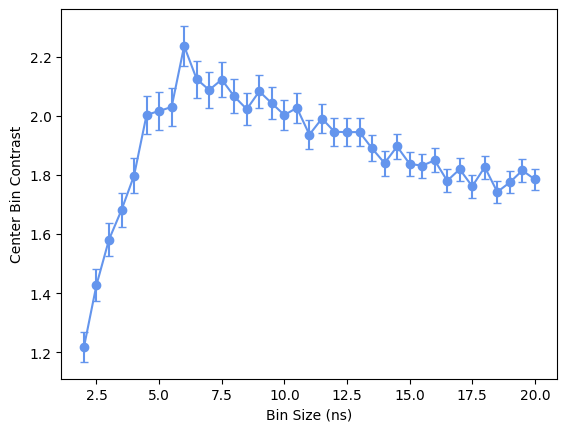

In [8]:
plt.errorbar(np.array(rebin_factors) * bin_size, contrast_vals, yerr=contrast_err,
             marker='o', capsize=3, color='cornflowerblue')
plt.xlabel('Bin Size (ns)')
plt.ylabel('Center Bin Contrast')

<ErrorbarContainer object of 3 artists>

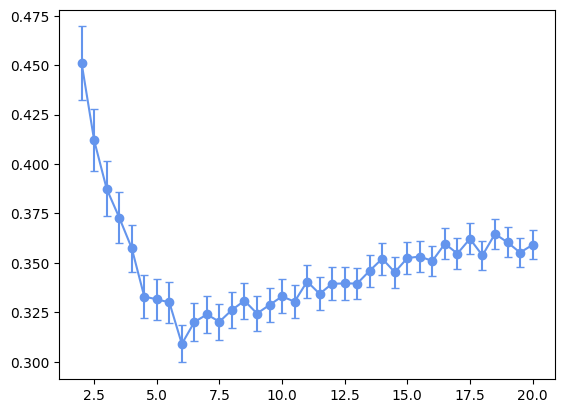

In [9]:
contrast_error = 1 / (contrast_vals + 1)
error_yerr = (contrast_err / contrast_vals) * (1 / (contrast_vals + 1))
plt.errorbar(np.array(rebin_factors) * bin_size, contrast_error, yerr=error_yerr,
             marker='o', capsize=3, color='cornflowerblue')

## Subfigure (a): Coincidence 2D Histogram

In [10]:
offset_0 = -echo_center
rebinned_array = shrink_array_roll(all_hist, factor=rebin_factor, offset_0=offset_0)

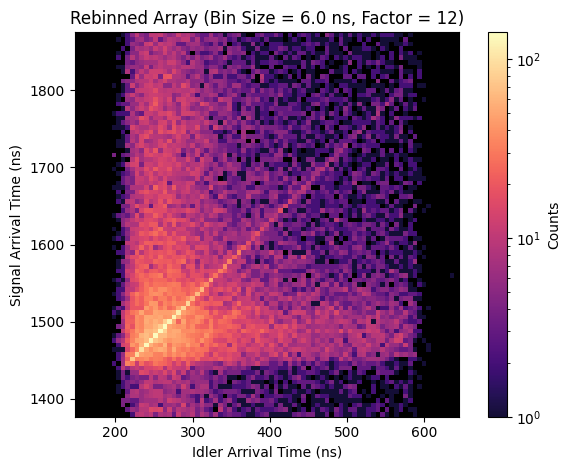

In [11]:
# plot summed histogram (zoom on echo)
signal_start = (idler_lim_input[0] + signal_idler_offset_guess + 2000) // rebin_factor + 1
signal_end = (idler_lim_input[1] + signal_idler_offset_guess + 2000) // rebin_factor + 1
idler_start = idler_lim_input[0] // rebin_factor
idler_end = idler_lim_input[1] // rebin_factor
echo_zoom = rebinned_array[signal_start:signal_end, idler_start:idler_end]

signal_time_bins = np.arange(signal_start, signal_end) * rebin_factor * bin_size
idler_time_bins = np.arange(idler_start, idler_end) * rebin_factor * bin_size
X, Y = np.meshgrid(idler_time_bins, signal_time_bins)

# plot log scale
plt.pcolormesh(X, Y, echo_zoom, cmap=new_cmap,
               norm=colors.LogNorm(vmin=1, vmax=echo_zoom.max()))
plt.gca().set_facecolor('black')
plt.gca().set_aspect('equal')
plt.xlabel('Idler Arrival Time (ns)')
plt.ylabel('Signal Arrival Time (ns)')
plt.colorbar(label='Counts')
plt.title(f'Rebinned Array (Bin Size = {rebin_factor * bin_size} ns, Factor = {rebin_factor})')
plt.tight_layout()

## Subfigure (b): Diagonal Coincidence Bins

In [12]:
time_bin_diagonal = np.diagonal(echo_zoom)
bin_numbers = np.arange(len(time_bin_diagonal))

In [13]:
# define starting and ending bins
start_bin = 10
frame_size = 63

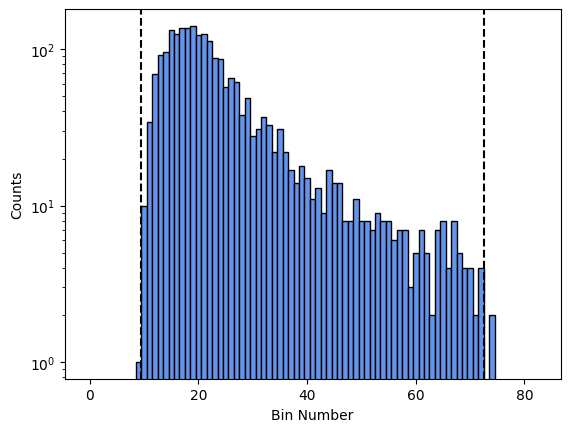

In [14]:
plt.bar(bin_numbers, time_bin_diagonal, width=1, color='cornflowerblue', edgecolor='k')
plt.axvline(x=start_bin-0.5, color='k', linestyle='--')
plt.axvline(x=start_bin+frame_size-0.5, color='k', linestyle='--')
plt.xlabel('Bin Number')
plt.ylabel('Counts')
plt.yscale('log')

## Subfigure (c): Performance Characterization

# Main Plot Code

First, define plotting parameters

In [15]:
# matplotlib general (and font)
mpl.rcParams.update({'font.sans-serif': 'Arial',
                     'font.size': 7})
figwidth_mm = 90
figsize = (figwidth_mm/25.4, 5)  # inches
dpi = 300
include_subplot_titles = False

# colors
color_primary = '#7570b3'
color_secondary = '#d95f02'
color_tertiary = '#1b9e77'

# figure layout
vertical_padding = 0.05
horizontal_padding = 0.05

Text(0, 0.5, 'Counts')

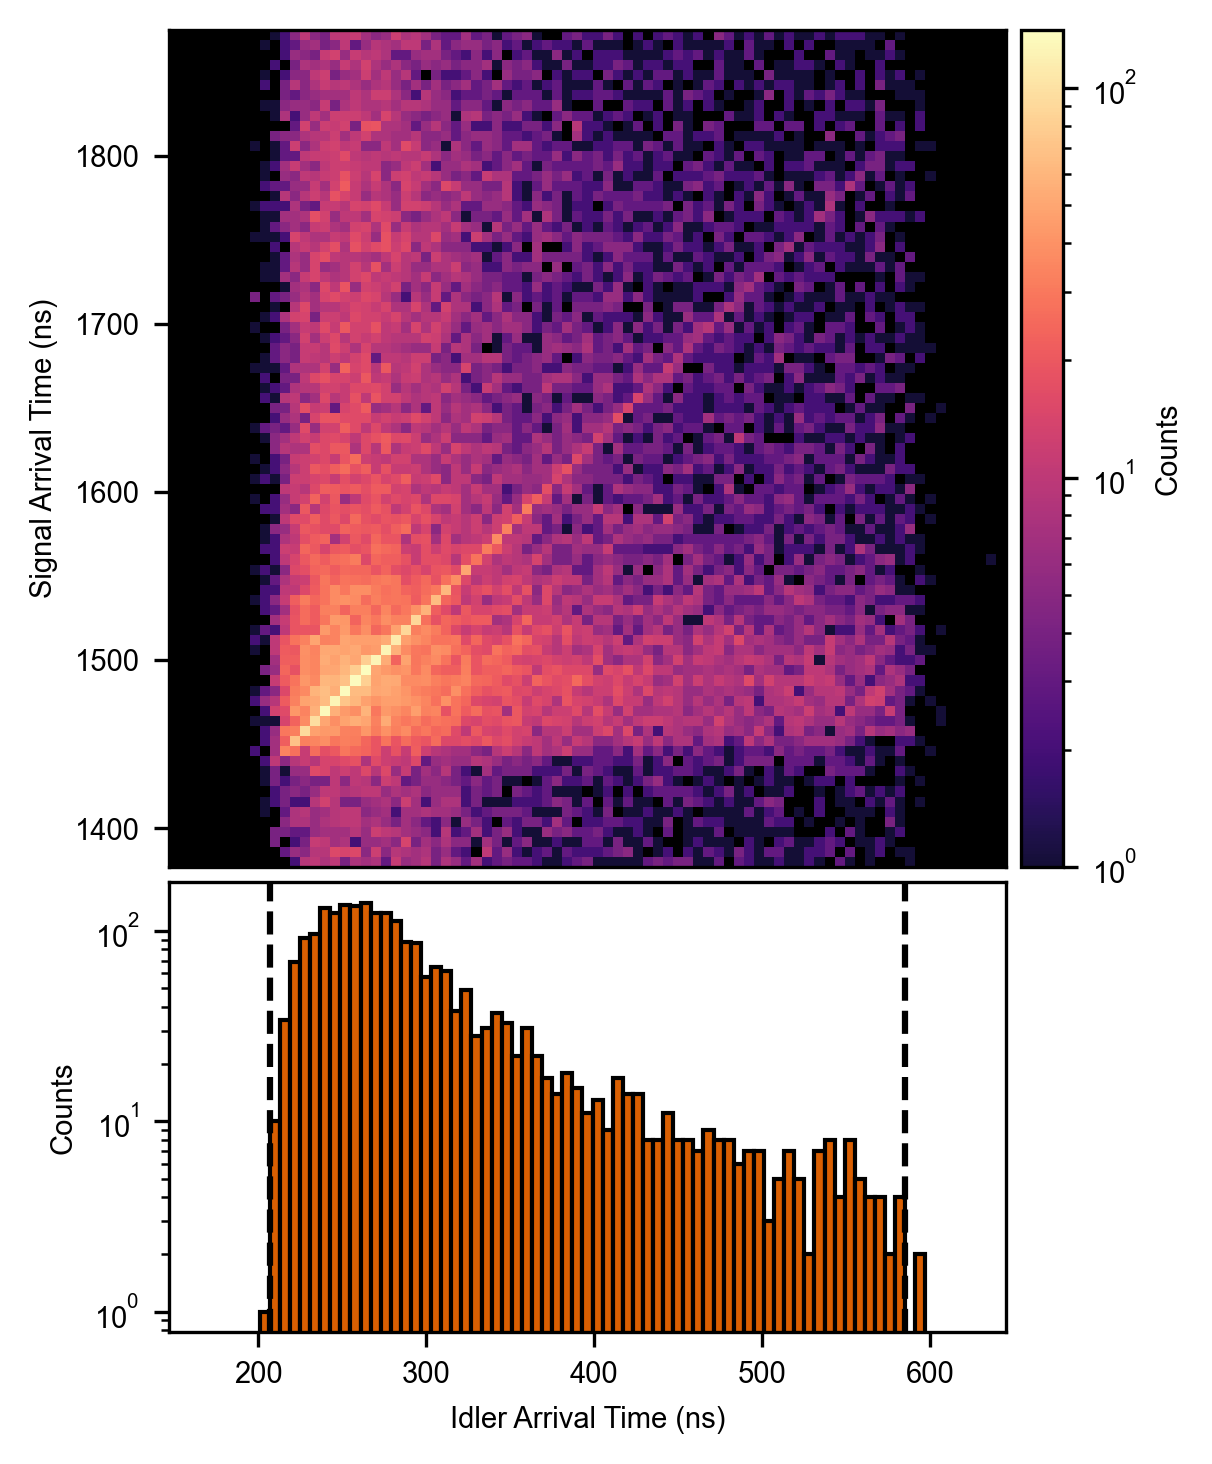

In [20]:
fig = plt.figure(layout='constrained', figsize=figsize, dpi=dpi)
fig.get_layout_engine().set(w_pad=horizontal_padding, h_pad=vertical_padding)
subfigs = fig.subfigures()
ax_mid = subfigs.subplots()

plot = ax_mid.pcolormesh(X, Y, echo_zoom, cmap=new_cmap,
                         norm=colors.LogNorm(vmin=1, vmax=echo_zoom.max()))
ax_mid.set_facecolor('black')
ax_mid.axes.set_aspect('equal')
ax_mid.set_ylabel('Signal Arrival Time (ns)')
ax_mid.xaxis.set_visible(False)
# ax_mid.xaxis.set_tick_params(labeltop=True,
#                              labelbottom=False,
#                              top=True,
#                              bottom=False)
# ax_mid.xaxis.set_label_position('top')
# ax_mid.set_xlabel('Idler Arrival Time (ns)')

divider = make_axes_locatable(ax_mid)
ax_bot = divider.append_axes('bottom', 1.5, pad=0.05, sharex=ax_mid)
cax = divider.append_axes('right', size='5%', pad=0.05)
subfigs.colorbar(plot, cax=cax, label='Counts', ax=ax_mid)

ax_bot.bar(idler_time_bins, time_bin_diagonal,
           width=rebin_factor*bin_size, edgecolor='k', color=color_secondary)
ax_bot.axvline(idler_time_bins[start_bin] - rebin_factor*bin_size/2, color='k', linestyle='--')
ax_bot.axvline(idler_time_bins[start_bin+frame_size] - rebin_factor*bin_size/2, color='k', linestyle='--')
ax_bot.set_yscale('log')
ax_bot.set_xlabel('Idler Arrival Time (ns)')
ax_bot.set_ylabel('Counts')

In [21]:
fig.savefig('fig4.pdf', bbox_inches='tight')